In [7]:
import bagpipes as pipes
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import AutoMinorLocator
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import matplotlib.patches as patches
mpl.rcParams['font.family'] = 'serif'
config = {
    "font.size": 18,
    "figure.figsize": (25, 14),

    "axes.titlesize": 28,        # ax.set_title fontsize
    "axes.labelsize": 24,        # ax.set_xlabel/ylabel fontsize
    "legend.fontsize": 20,       # ax.legend fontsize
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    "axes.linewidth": 2,         # 对应 ax.spines...linewidth
    "axes.edgecolor": "black",   # 对应 ax.spines...color

    "xtick.direction": "in",     # direction='in'
    "ytick.direction": "in",
    "xtick.top": True,           # ax.xaxis.set_ticks_position('both')
    "ytick.right": True,         # ax.yaxis.set_ticks_position('both')

    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.width": 2,      # which='both' implies minor too
    "ytick.minor.width": 2,

    "xtick.major.size": 6,       # length=6 major
    "ytick.major.size": 6,
    "xtick.minor.size": 3,       # length=3 minor
    "ytick.minor.size": 3,
}
plt.rcParams.update(config)
from matplotlib.ticker import AutoMinorLocator


from astropy import units as u
from tqdm import tqdm
from scipy.integrate import quad

---
## Here is the constant sfh model for different ages.

100%|██████████| 5/5 [00:06<00:00,  1.37s/it]


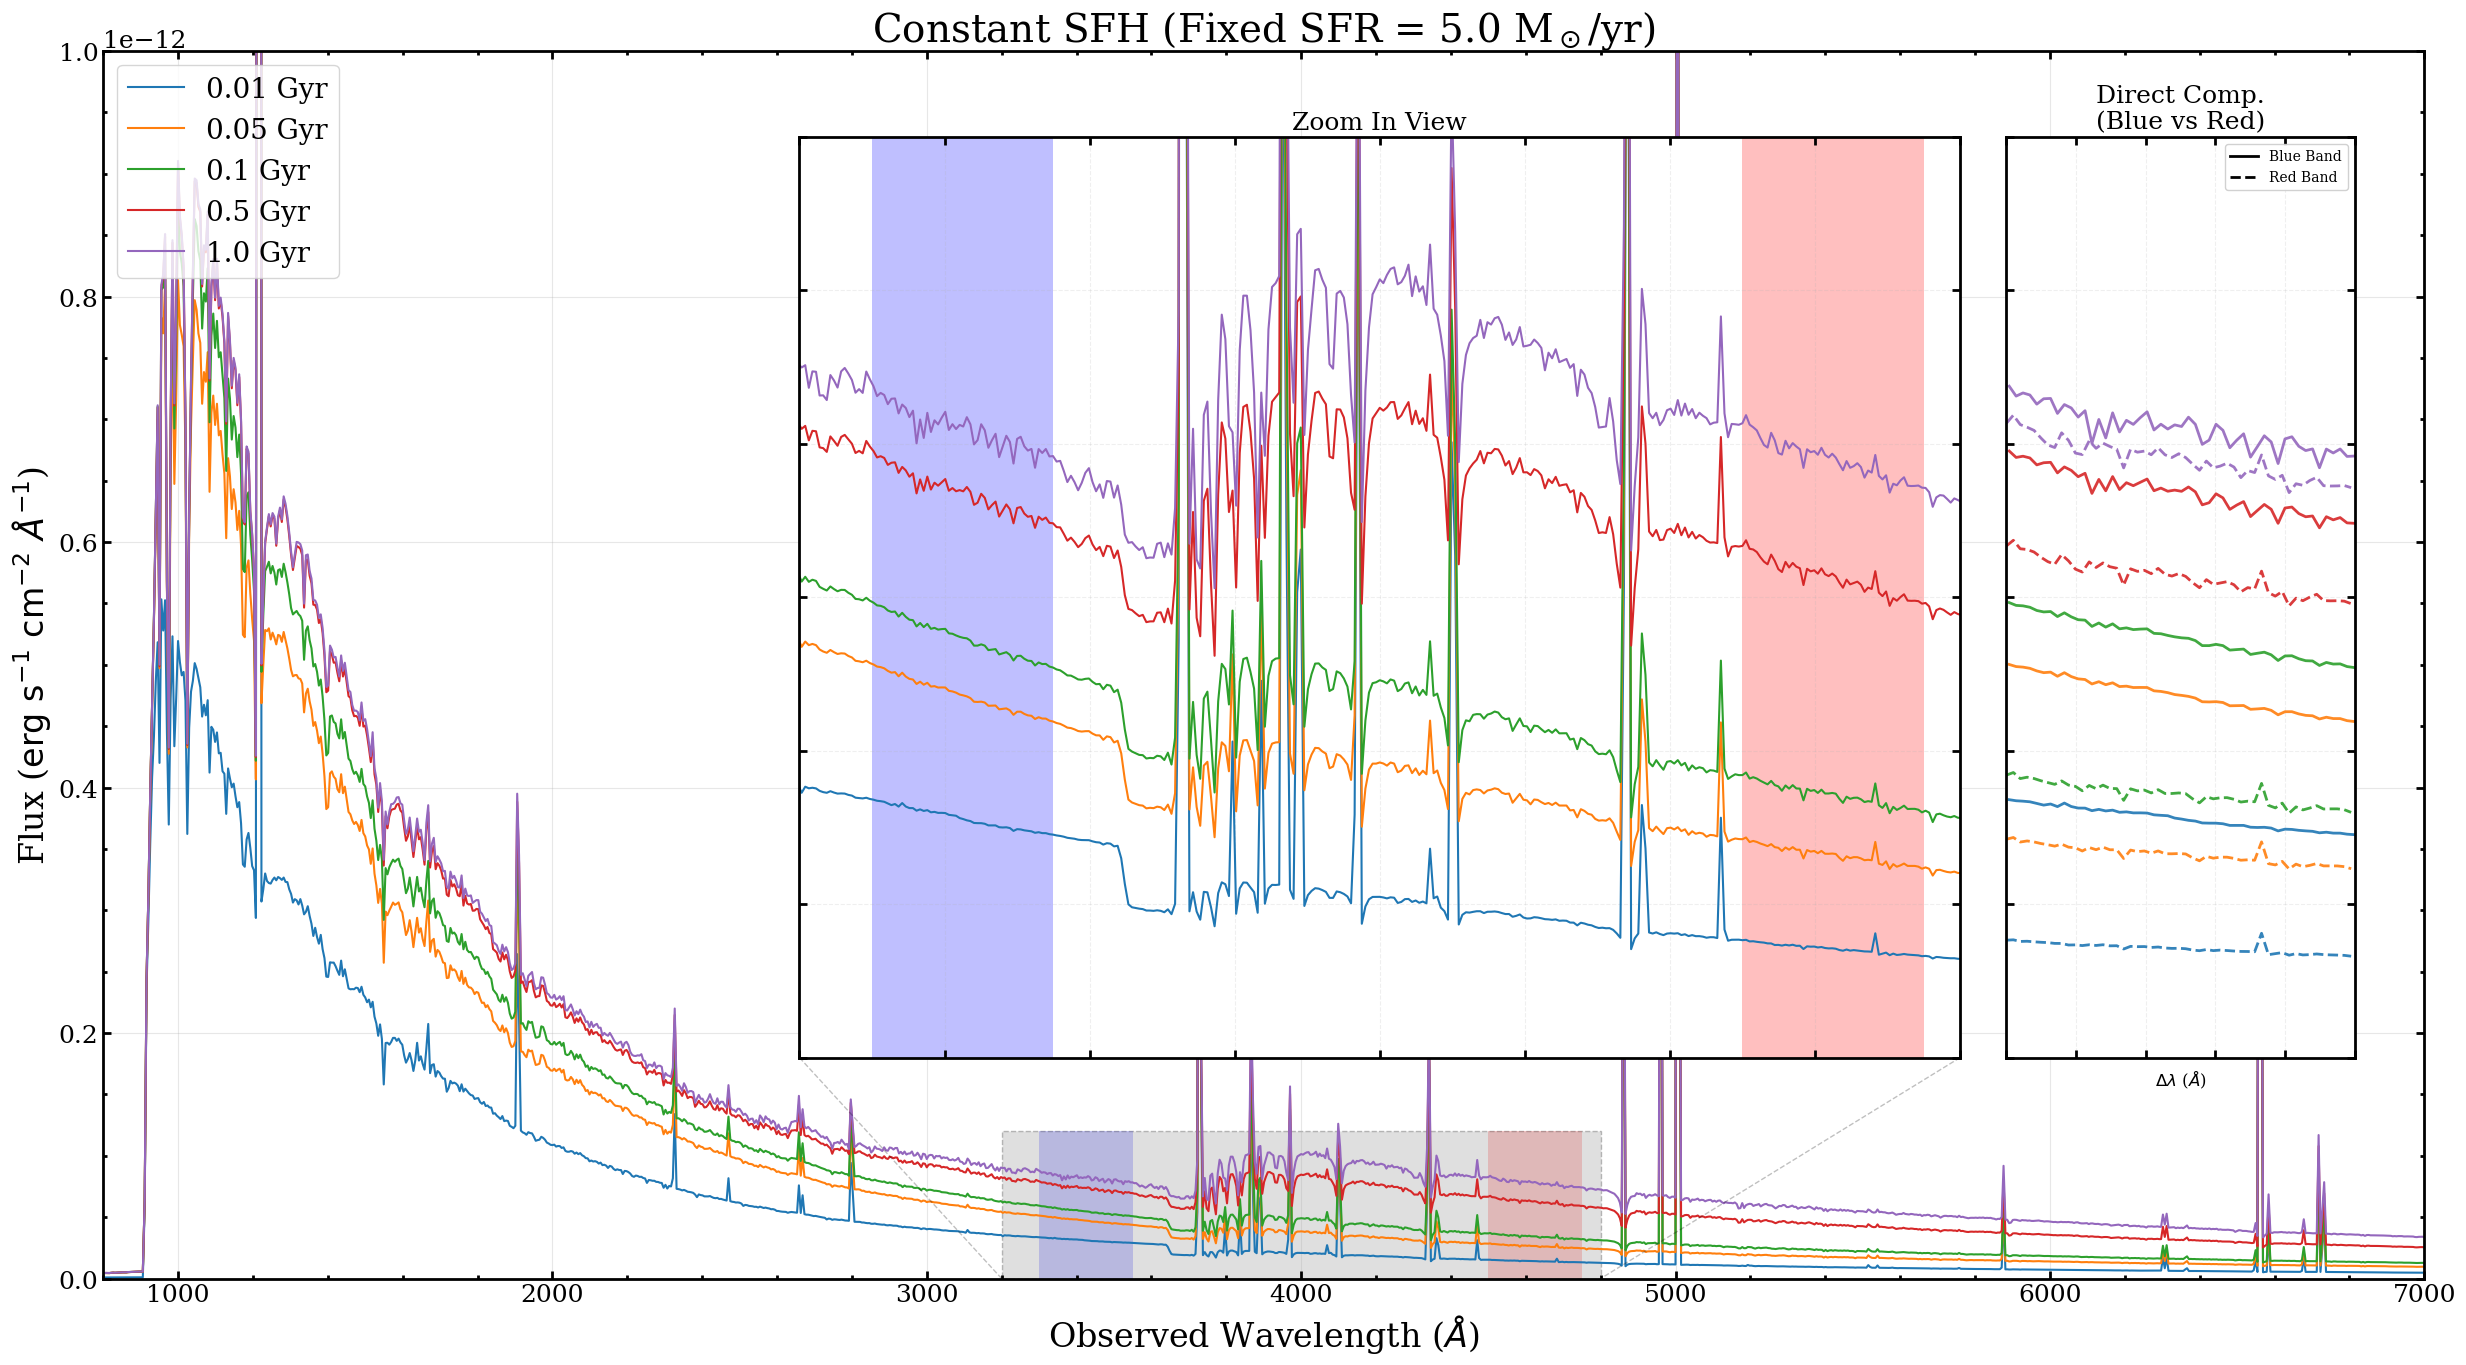

In [8]:
age_list=[0.01,0.05,0.1,0.5,1.0]
target_sfr=5.0
constant_sfh = {}
constant_sfh["age_min"] = 0.0
constant_sfh["metallicity"] = 0.2

nebular = {}
nebular["logU"] = -2.5

model_components = {}
model_components["redshift"] = 0.01
model_components["constant"] = constant_sfh
model_components["nebular"] = nebular
waves_arrays=np.array([])
flux_arrays=np.array([])
for age in tqdm(age_list):

# 1. 更新年龄
    model_components["constant"]["age_max"] = age

    # 2. 更新质量 (Mass = SFR * Age)
    total_mass = target_sfr * (age * 1e9)
    model_components["constant"]["massformed"] = np.log10(total_mass)

    # 3. 生成模型 (只覆盖 3000-5000A 即可)
    model = pipes.model_galaxy(model_components, spec_wavs=np.arange(500, 8000, 5))
    wave = model.spectrum[:, 0]/1.01
    flux = model.spectrum[:, 1]*1.01
    if waves_arrays.size==0:
        waves_arrays=wave
        flux_arrays=flux
    else:
        waves_arrays=np.column_stack((waves_arrays,wave))
        flux_arrays=np.column_stack((flux_arrays,flux))


fig, ax = plt.subplots(figsize=(25, 14))


for i in range(len(age_list)):
    ax.plot(waves_arrays[:,i], flux_arrays[:,i], label=f"{age_list[i]} Gyr")

ax.set_xlabel(f"Observed Wavelength ($\AA$)")
ax.set_ylabel("Flux ($\\text{erg}\ \\text{s}^{-1}\ \\text{cm}^{-2}\ \\AA^{-1}$)")
ax.set_title(f"Constant SFH (Fixed SFR = {target_sfr} M$_\odot$/yr)")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1e-12)
ax.set_xlim(800,7000)

rect_blue = patches.Rectangle((3300, 0), 250, 1.2e-13, facecolor='blue', alpha=0.2, edgecolor='none')
rect_red  = patches.Rectangle((4500, 0), 250, 1.2e-13, facecolor='red', alpha=0.2, edgecolor='none')
ax.add_patch(rect_blue)
ax.add_patch(rect_red)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())



axins_zoom = ax.inset_axes([0.3, 0.18, 0.5, 0.75])
axins_comp = ax.inset_axes([0.82, 0.18, 0.15, 0.75])


ylim_inset = 1.2e-13


for i in range(len(age_list)):
    axins_zoom.plot(waves_arrays[:,i], flux_arrays[:,i])

axins_zoom.fill_between([3300, 3550], 0, ylim_inset, facecolor='blue', alpha=0.25)
axins_zoom.fill_between([4500, 4750], 0, ylim_inset, facecolor='red', alpha=0.25)

axins_zoom.set_xlim(3200, 4800)
axins_zoom.set_ylim(0, ylim_inset)
axins_zoom.tick_params(axis='both', labelsize=12)
axins_zoom.set_title("Zoom In View", fontsize=18)
axins_zoom.grid(True, alpha=0.2, linestyle='--')
axins_zoom.set_xticklabels([])
axins_zoom.set_yticklabels([])

mark_inset(ax, axins_zoom, loc1=3, loc2=4, fc="gray", alpha=0.25, ec="k", lw=1, linestyle='--')


blue_start = 3300
red_start = 4500
span = 250 # 两个区域都是300A宽

for i in range(len(age_list)):
    # 获取颜色以便匹配
    color = plt.rcParams['axes.prop_cycle'].by_key()['color'][i % 10]

    w = waves_arrays[:,i]
    f = flux_arrays[:,i]

    # --- 蓝色部分 (实线) ---
    mask_b = (w >= blue_start) & (w <= blue_start + span)
    axins_comp.plot(w[mask_b] - blue_start, f[mask_b],
                    color=color, linestyle='-', linewidth=2, alpha=0.9)

    # --- 红色部分 (虚线) ---
    mask_r = (w >= red_start) & (w <= red_start + span)
    axins_comp.plot(w[mask_r] - red_start, f[mask_r],
                    color=color, linestyle='--', linewidth=2, alpha=0.9)

# 设置范围和样式
axins_comp.set_xlim(0, span)
axins_comp.set_ylim(0, ylim_inset)
axins_comp.set_title("Direct Comp.\n(Blue vs Red)", fontsize=18)
axins_comp.set_xlabel(r"$\Delta \lambda$ ($\AA$)", fontsize=12)

# 为了美观，右图的Y轴刻度可以隐藏（因为和左图对齐），或者保留看你喜好
axins_comp.set_yticklabels([])
axins_comp.tick_params(axis='x', labelsize=12)
axins_comp.grid(True, alpha=0.2, linestyle='--')
axins_comp.set_xticklabels([])
axins_comp.set_yticklabels([])

# 添加一个小图例解释线型
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='k', lw=2, label='Blue Band', linestyle='-'),
                   Line2D([0], [0], color='k', lw=2, label='Red Band', linestyle='--')]
axins_comp.legend(handles=legend_elements, loc='upper right', fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.savefig("bagpipes_constant_SFR.pdf")
plt.show()

### Here is the different SFR with time.

In [ ]:
# --- 1. 定义参数 ---
# 我们选择几个跨度较大的 SFR，来验证比值是否与 SFR 无关
sfr_list = [1.0, 5.0, 10.0, 50.0]
# 基础模型配置
constant_sfh = {}
constant_sfh["age_min"] = 0.0
constant_sfh["metallicity"] = 0.2

nebular = {}
nebular["logU"] = -2.5

model_components = {}
model_components["redshift"] = 0.05
model_components["constant"] = constant_sfh
model_components["nebular"] = nebular

# --- 2. 准备循环 ---
age_list = np.arange(0.01, 1.01, 0.2) # 从 10 Myr 到 1 Gyr

# 定义波长区间
b_left, b_right = 3250, 3550
r_left, r_right = 4450, 4750

# 绘图设置
plt.figure(figsize=(25, 14))
# 使用不同的线型，以便如果它们重合，我们能看出来
linestyles = ['-', '--', '-.', ':']

print("正在计算颜色比值 (Blue/Red Ratio)...")

for i, target_sfr in enumerate(sfr_list):

    ratios = [] # 存储比值

    for age in tqdm(age_list, desc=f"SFR = {target_sfr}", leave=False):


        model_components["constant"]["age_max"] = age


        total_mass = target_sfr * (age * 1e9)
        model_components["constant"]["massformed"] = np.log10(total_mass)


        model = pipes.model_galaxy(model_components, spec_wavs=np.arange(3000, 5000, 50))
        wave = model.spectrum[:, 0]
        flux = model.spectrum[:, 1]


        # Blue Integral
        fluxsum=0
        wavesum=0
        mask_b = (wave >= b_left) & (wave <= b_right)
        for i in range(len(flux[mask_b])):
            left=wave[mask_b][i]
            right=wave[mask_b][i+1] if i+1<len(flux[mask_b]) else wave[mask_b][i]+50

            fluxsum+=flux[mask_b][i]*(right-left)
            wavesum+=right-left
        int_b = fluxsum/wavesum


        # Red Integral
        mask_r = (wave >= r_left) & (wave <= r_right)
        fluxsum=0
        wavesum=0
        for i in range(len(flux[mask_r])):
            left=wave[mask_r][i]
            right=wave[mask_r][i+1] if i+1<len(flux[mask_r]) else wave[mask_r][i]+50

            fluxsum+=flux[mask_r][i]*(right-left)
            wavesum+=right-left
        int_r = fluxsum/wavesum
        ratios.append(int_b / int_r)


    plt.plot(age_list, ratios,
             label=f"SFR = {target_sfr} $M_\odot/yr$",
             linestyle=linestyles[i % len(linestyles)],
             linewidth=3.5 - i*0.8)

plt.xlabel("Age of Galaxy (Gyr)", fontsize=14)
plt.ylabel(f"Flux Ratio (Blue / Red)\n[{b_left}-{b_right}$\AA$ / {r_left}-{r_right}$\AA$]", fontsize=14)
plt.title("Evolution of Color (Flux Ratio) with Stellar Age", fontsize=16)

plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.text(0.5, 0.8, "Note: Lines overlap because Color is\nindependent of absolute SFR scale",
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8))
plt.show()

正在计算颜色比值 (Blue/Red Ratio)...


ValueError: All values in the dash list must be non-negative

<Figure size 2500x1400 with 1 Axes>

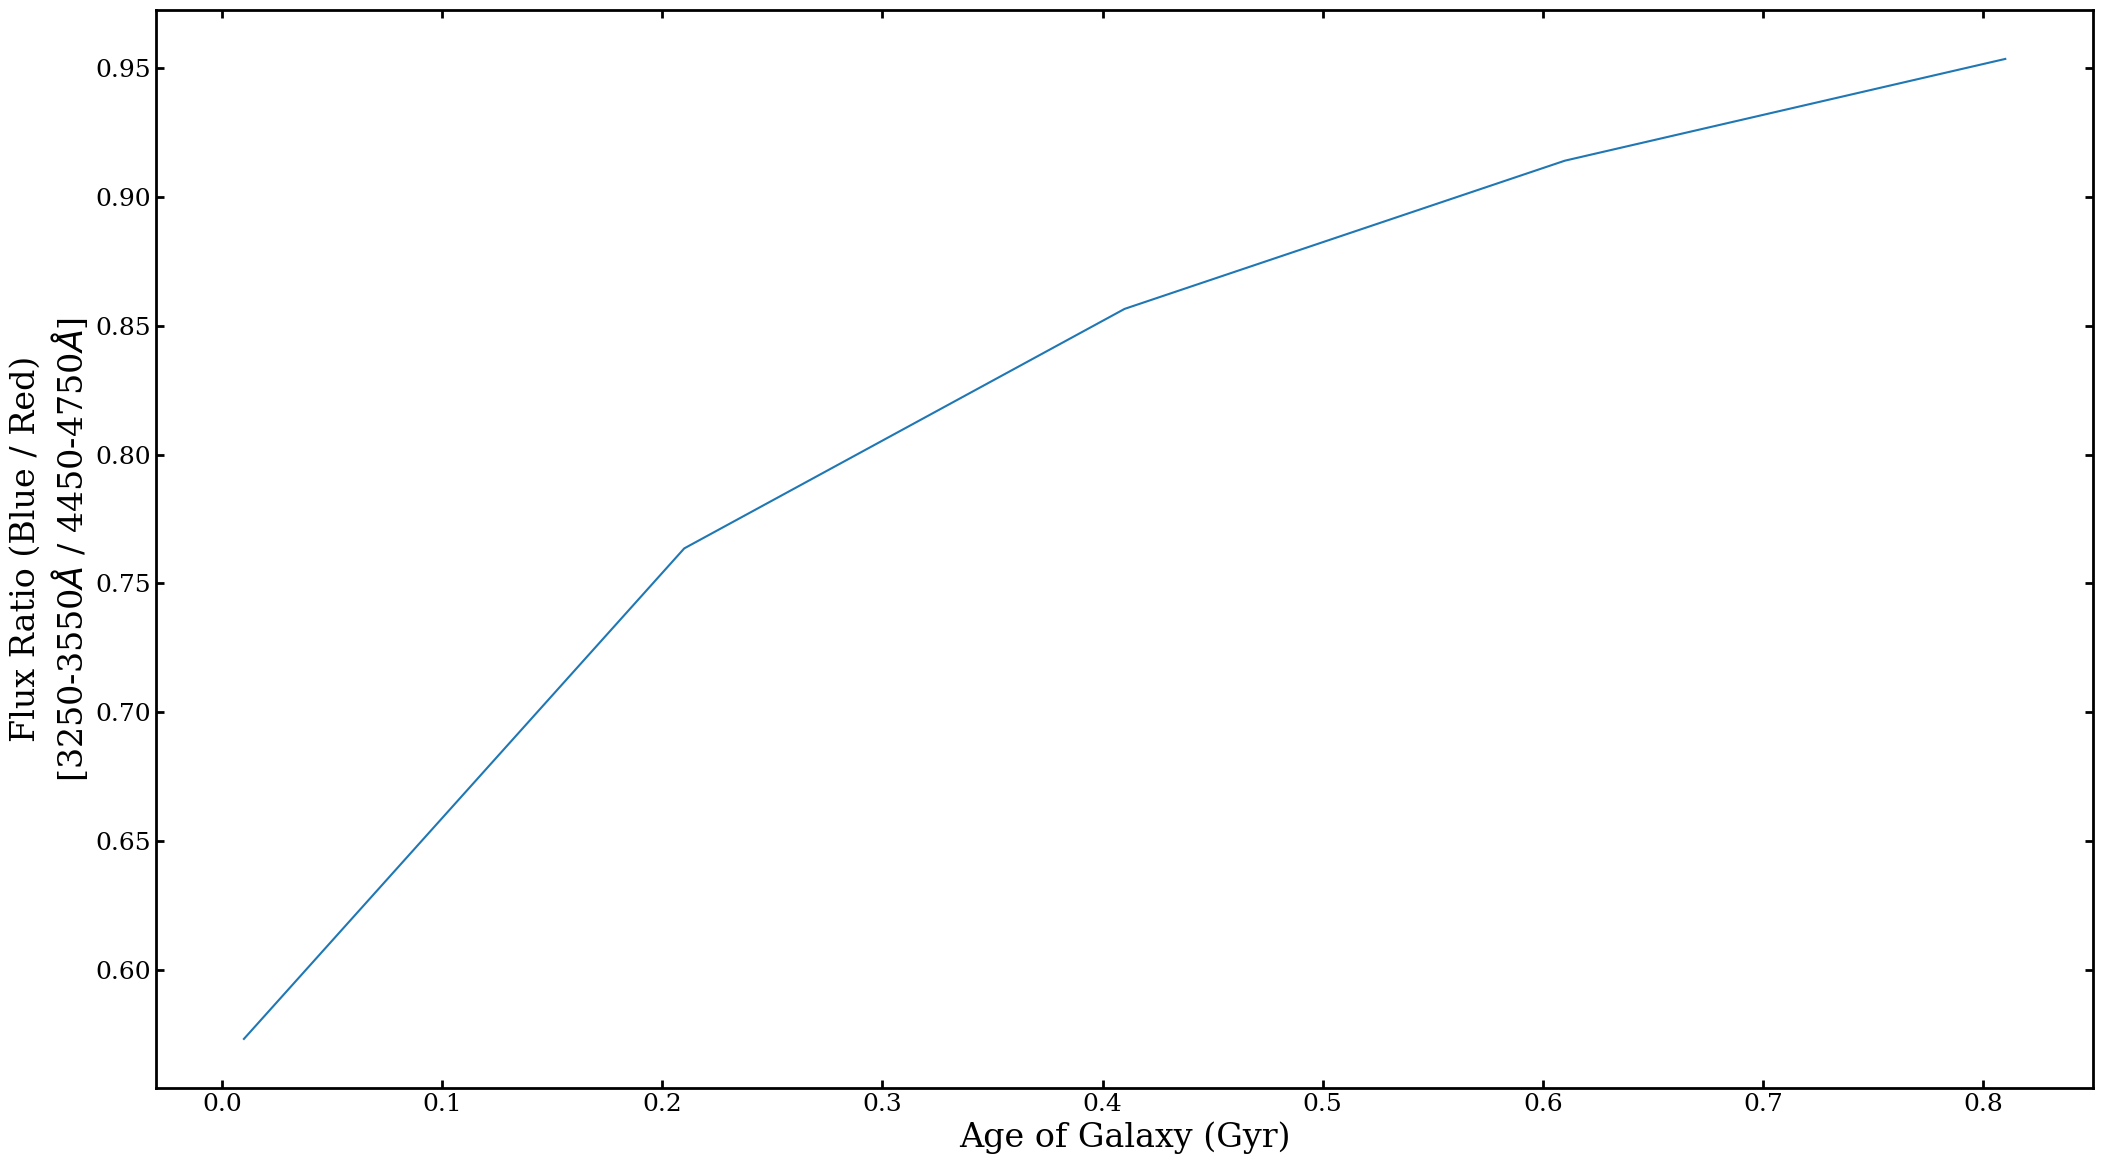

In [6]:
fig, ax=plt.subplots(figsize=(25,14))
ax.set_xlabel("Age of Galaxy (Gyr)", fontsize=24)
ax.set_ylabel(f"Flux Ratio (Blue / Red)\n[{b_left}-{b_right}$\AA$ / {r_left}-{r_right}$\AA$]", fontsize=24)
ax.plot(age_list, 1./np.array(ratios))
# plt.xlabel("Age of Galaxy (Gyr)", fontsize=14)

In [ ]:
# 1. 定义恒星形成历史 (Constant SFH)
target_sfr = 5.0  # Solar masses per year (Constant SFR)

constant_sfh = {}
constant_sfh["age_min"] = 0.0     # Star formation continues until observation
constant_sfh["metallicity"] = 0.05 # Solar metallicity


# 2. !!! 关键步骤：定义星云发射 (Nebular Emission) !!!
nebular = {}
nebular["logU"] = -3.0  # 电离参数 (无量纲，通常 -4 到 -2)
# 你也可以设置 nebular["f_esc"] 来控制光子逃逸率，默认为 0 (全部用于电离)

# 3. 组装模型
model_components = {}
model_components["redshift"] = 0.1  # 设为0以便我们在静止波长看 H-alpha (6563 A)
model_components["constant"] = constant_sfh
model_components["nebular"] = nebular  # <--- 把 nebular 加入模型

age_list = [0.1, 1.0, 5.0, 9.0]

plt.figure(figsize=(25, 14))

for age in age_list:
    # Set the start time of star formation
    model_components["constant"]["age_max"] = age

    total_mass = target_sfr * (age * 1e9)

    # Bagpipes takes Log10 of mass formed
    model_components["constant"]["massformed"] = np.log10(total_mass)

    # Generate model
    model = pipes.model_galaxy(model_components, spec_wavs=np.arange(3000, 5200, 5))

    plt.plot(model.spectrum[:, 0], model.spectrum[:, 1],
             label=f"Age: {age} Gyr (Mass: {total_mass:.1e} $M_\odot$)")

# # 为了对比，我们生成一个没有发射线的版本
# del model_components["nebular"]
# model_no_lines = pipes.model_galaxy(model_components, spec_wavs=wavs)
# plt.plot(model_no_lines.spectrum[:, 0], model_no_lines.spectrum[:, 1], 'r--', alpha=0.6, label="Stellar Continuum Only")

plt.xlabel("Wavelength ($\AA$)")
plt.ylabel("Flux")
plt.title("Bagpipes Model with Nebular Emission Lines")
plt.legend()
plt.show()

KeyboardInterrupt: 

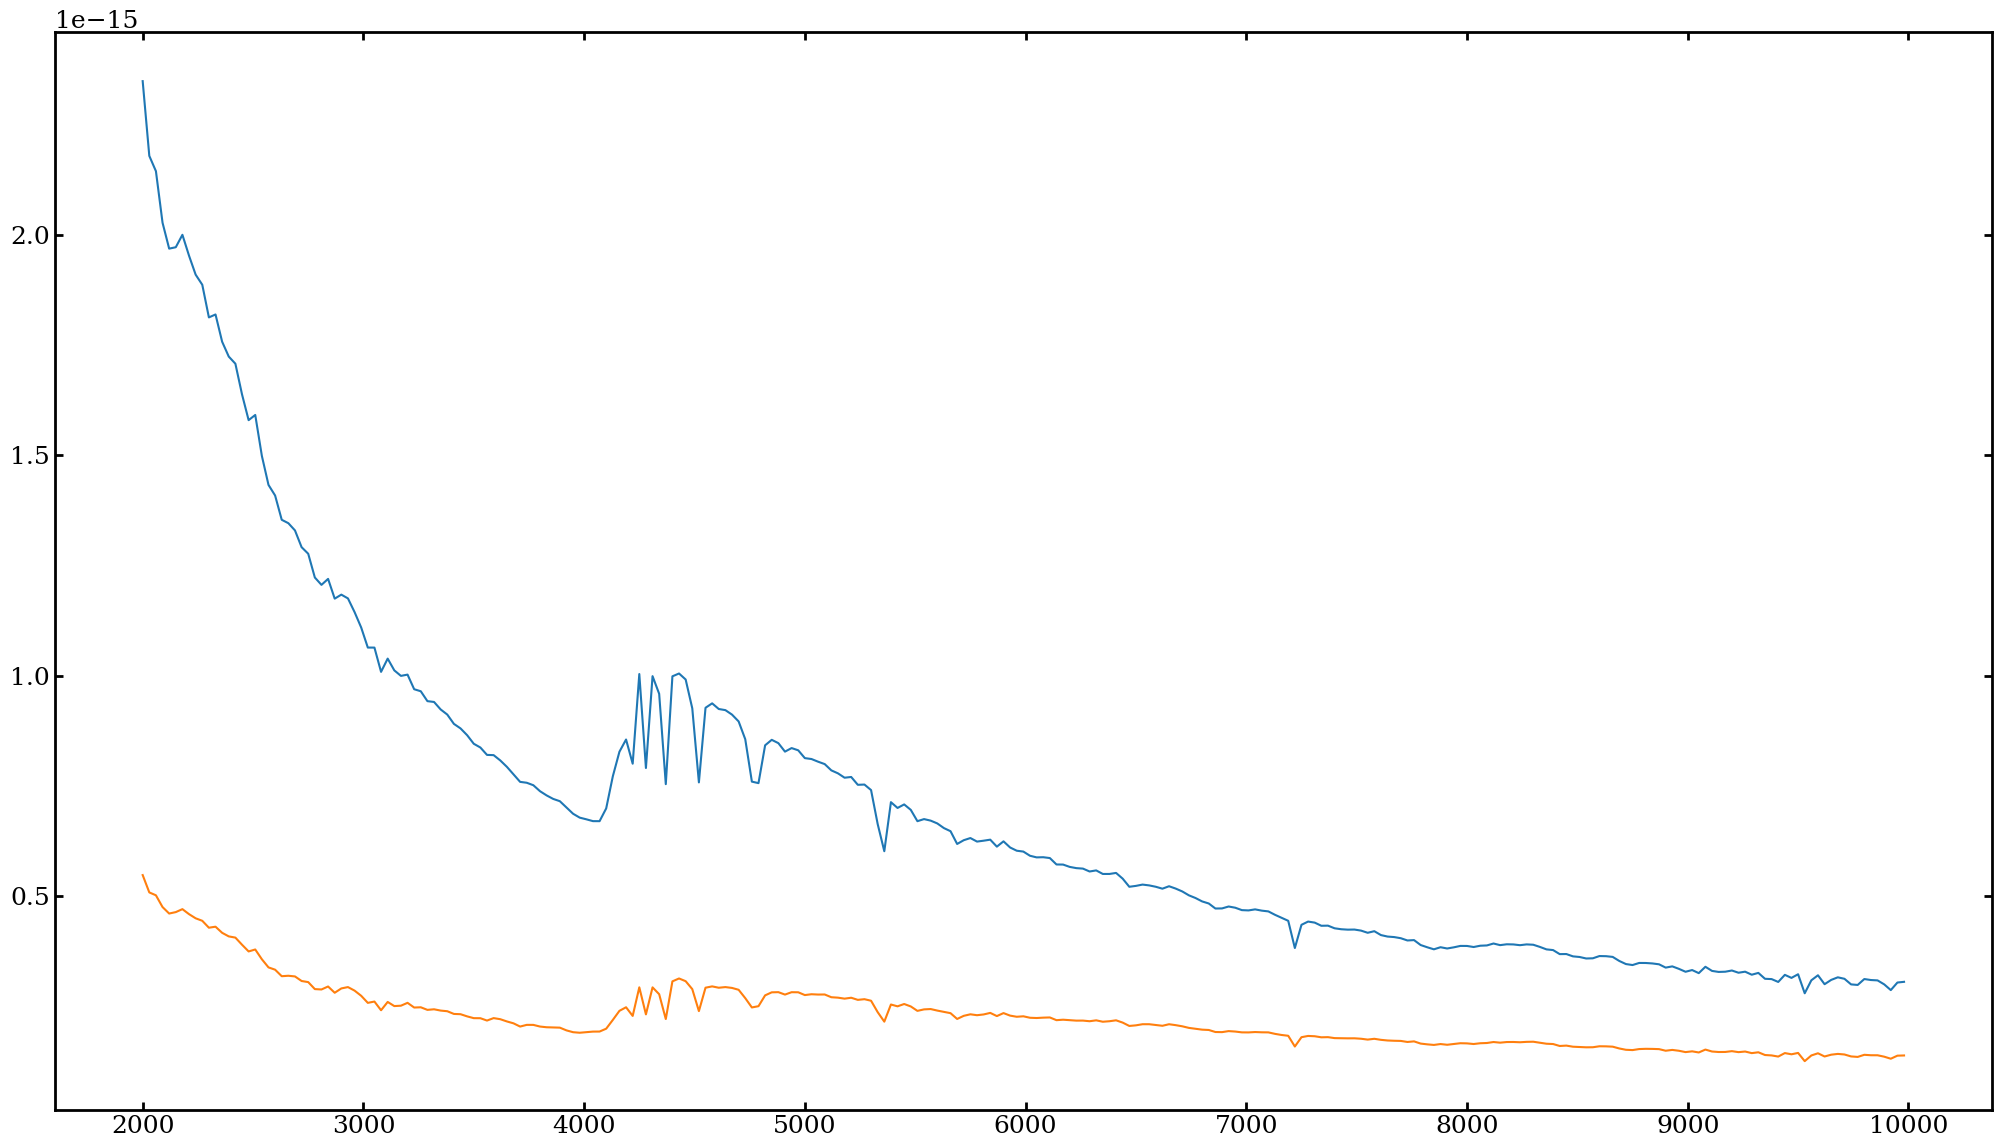

In [14]:

# 1. Define the base model components
# We will use a 'delayed' exponentially declining SFH.
delayed_sfh = {}
delayed_sfh["tau"] = 2.0           # Decay timescale in Gyr
delayed_sfh["massformed"] = 10.0   # Log10 total stellar mass formed
delayed_sfh["metallicity"] = 1.0   # Solar metallicity (Z/Z_sol)

# Create the main dictionary
model_components = {}
model_components["redshift"] = 0.1 # Fixed redshift for observation
model_components["delayed"] = delayed_sfh

# Optional: Add dust or nebular emission if desired
dust = {}
dust["type"] = "Calzetti"
dust["Av"] = 0.5
model_components["dust"] = dust

# 2. Define a list of ages (Time since star formation began in Gyr)
age_list = [1.0, 3.0, 5.0, 9.0]

# 3. Loop through ages and generate models
plt.figure(figsize=(25, 14))

for age in age_list:
    # Update the age parameter in the specific SFH component
    # Note: 'age' is in Gyr
    model_components["delayed"]["age"] = age

    # Create the model galaxy
    # The 'spec_wavs' argument defines the wavelength grid (Angstroms)
    model = pipes.model_galaxy(model_components, spec_wavs=np.arange(2000, 10000, 30))

    # Access the spectrum
    # model.spectrum is a 2D array: [wavelengths, fluxes]
    wavelengths = model.spectrum[:, 0]
    fluxes = model.spectrum[:, 1]*u.erg / (u.s * u.cm**2 * u.AA)
    # fluxes = fluxes.to(u.Jy, equivalencies=u.spectral_density(wavelengths * u.AA)).value

    # Plot the result
    plt.plot(wavelengths, fluxes, label=f"Age = {age} Gyr")

# Formatting the plot
plt.xlabel("Observed Wavelength ($\AA$)")
plt.ylabel("Flux ($erg\ s^{-1}\ cm^{-2}\ \AA^{-1}$)")
plt.title("Model Galaxies with Fixed SFH Shape (Delayed Tau) and Varying Age")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 1. Define the burst component
# We keep massformed constant.
# This simulates the EXACT same cluster of stars observed at different times.
burst_sfh = {}
burst_sfh["massformed"] = 10.0   # Log10 total stellar mass
burst_sfh["metallicity"] = 1.0   # Solar metallicity

nebular = {}
nebular["logU"] = -3.0  # 电离参数 (无量纲，通常 -4 到 -2)

# Create the model components dictionary
model_components = {}
model_components["redshift"] = 0.1
model_components["burst"] = burst_sfh
model_components["nebular"] = nebular

# 2. Define a list of ages (Time since the burst happened in Gyr)
# Note: Very young ages (< 0.01 Gyr) might hit grid limits depending on isochrones
age_list = [0.01, 0.05, 0.1, 0.5, 1.0]

plt.figure(figsize=(25, 14))

for age in age_list:
    # Update the age parameter
    # This sets how long ago the burst occurred
    model_components["burst"]["age"] = age

    # Generate the model
    # We use a broad wavelength range to see the UV slope change
    model = pipes.model_galaxy(model_components, spec_wavs=np.arange(2000, 10000, 30))

    # Plot
    plt.plot(model.spectrum[:, 0], model.spectrum[:, 1],
             label=f"Age since burst: {age} Gyr")

# Formatting
plt.xlabel("Observed Wavelength ($\AA$)")
plt.ylabel("Flux ($erg\ s^{-1}\ cm^{-2}\ \AA^{-1}$)")
plt.title("Instant Burst (SSP) Passive Evolution")
plt.legend()
plt.yscale("log") # Log scale is often better for visualizing the huge drop in UV flux
plt.grid(True, alpha=0.3)
plt.show()

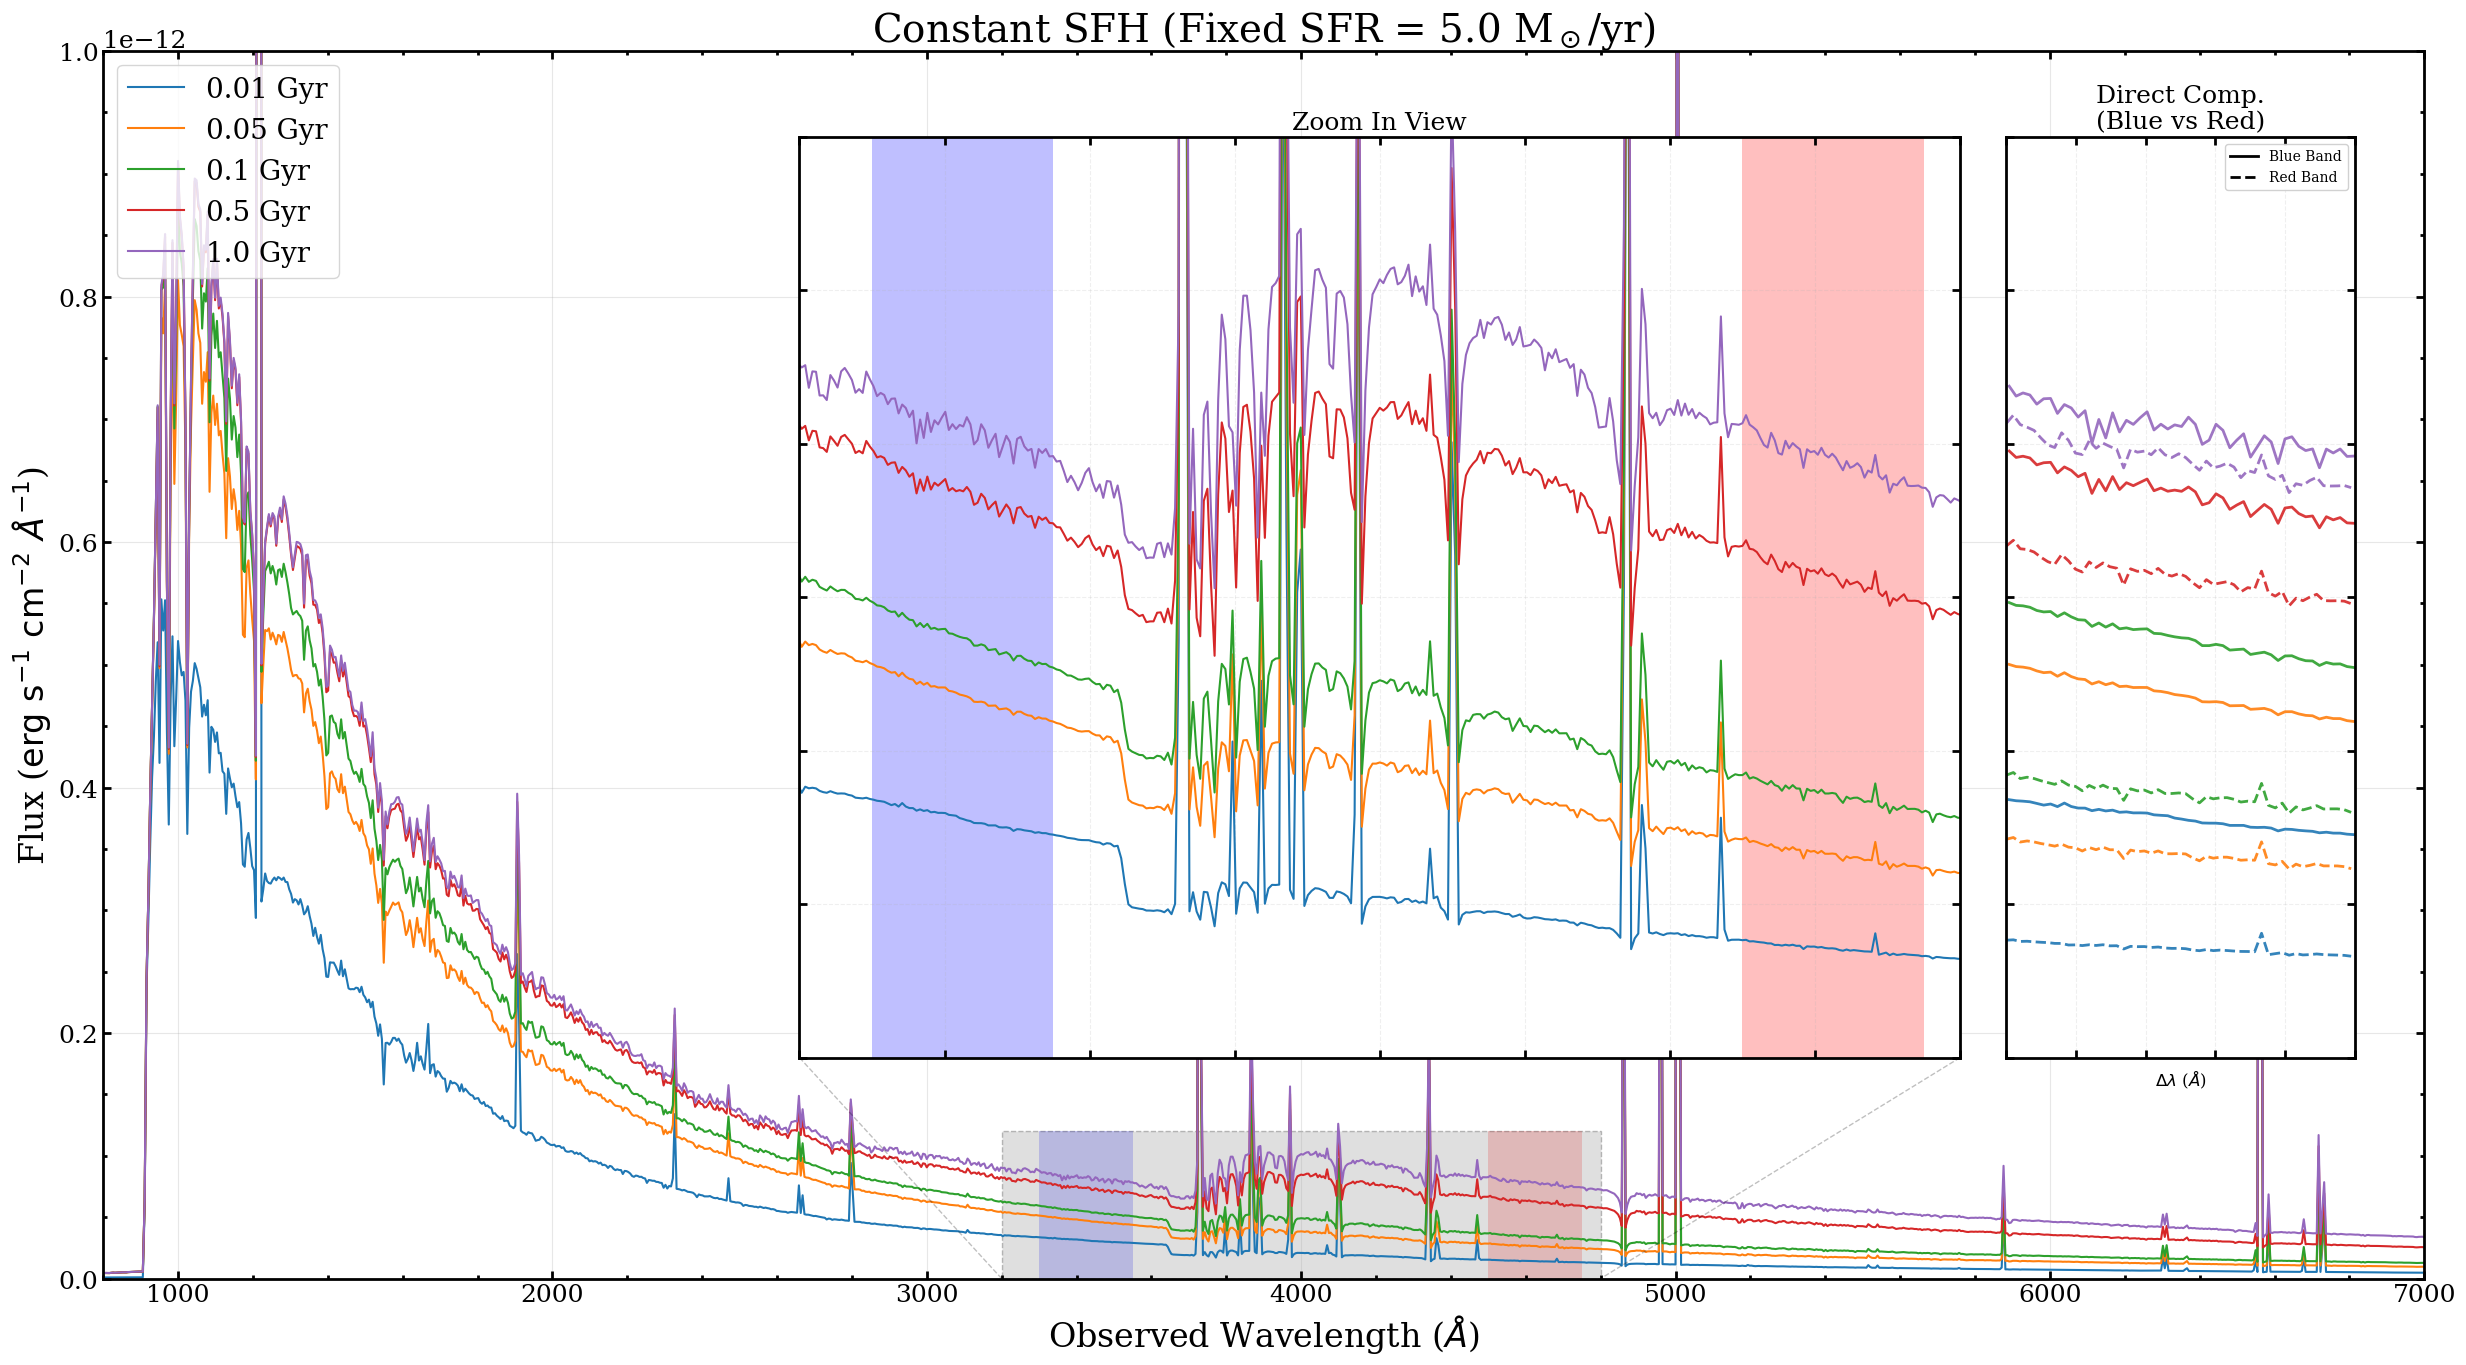

In [ ]:


# 假设你的数据变量依然是 waves_arrays, flux_arrays, age_list
# 这里直接开始画图逻辑



In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import matplotlib.patches as patches

# 假设你的数据变量依然是 waves_arrays, flux_arrays, age_list
# 这里直接开始画图逻辑

fig, ax = plt.subplots(figsize=(25, 14)) # 稍微加宽一点以容纳并列的小图

# ==========================================
# 1. 主图绘制 (Main Plot)
# ==========================================
for i in range(len(age_list)):
    ax.plot(waves_arrays[:,i], flux_arrays[:,i], label=f"{age_list[i]} Gyr")

ax.set_xlabel(f"Observed Wavelength ($\AA$)")
ax.set_ylabel("Flux ($\\text{erg}\ \\text{s}^{-1}\ \\text{cm}^{-2}\ \\AA^{-1}$)")
ax.set_title(f"Constant SFH (Fixed SFR = {target_sfr} M$_\odot$/yr)")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1e-12)
ax.set_xlim(800,7000)

# 主图上的阴影区域 (使用 Rectangle 对象更易管理)
rect_blue = patches.Rectangle((3300, 0), 250, 1.2e-13, facecolor='blue', alpha=0.2, edgecolor='none')
rect_red  = patches.Rectangle((4500, 0), 250, 1.2e-13, facecolor='red', alpha=0.2, edgecolor='none')
ax.add_patch(rect_blue)
ax.add_patch(rect_red)
# 虚线边框可以用 fill_between 补充或者单独画，这里为了简洁省略，保留你的fill_between习惯也可以

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

# ==========================================
# 2. 定义两个插图的位置 (Insets)
# ==========================================
# 原来是 [0.35, 0.35, 0.6, 0.6]
# 现在我们把它拆开：
# 左边 axins_zoom: 占据 0.38 宽
# 右边 axins_comp: 占据 0.20 宽
# 中间留 0.02 的间隙

axins_zoom = ax.inset_axes([0.3, 0.18, 0.5, 0.75])
axins_comp = ax.inset_axes([0.82, 0.18, 0.15, 0.75]) # 最右侧留出的0.2区域

# 设定两个区域的共同Y轴上限，保证比例一致
ylim_inset = 1.2e-13

# ==========================================
# 3. 左侧插图：物理波长 Zoom (3200-4800)
# ==========================================
for i in range(len(age_list)):
    axins_zoom.plot(waves_arrays[:,i], flux_arrays[:,i])

# 绘制标记区域 (Blue & Red)
axins_zoom.fill_between([3300, 3550], 0, ylim_inset, facecolor='blue', alpha=0.25)
axins_zoom.fill_between([4500, 4750], 0, ylim_inset, facecolor='red', alpha=0.25)

# 设置范围和样式
axins_zoom.set_xlim(3200, 4800)
axins_zoom.set_ylim(0, ylim_inset)
axins_zoom.tick_params(axis='both', labelsize=12)
axins_zoom.set_title("Zoom In View", fontsize=18)
axins_zoom.grid(True, alpha=0.2, linestyle='--')
axins_zoom.set_xticklabels([])
axins_zoom.set_yticklabels([])

# 连接线只连接左侧这个图，视觉上更清晰
mark_inset(ax, axins_zoom, loc1=3, loc2=4, fc="gray", alpha=0.25, ec="k", lw=1, linestyle='--')


# ==========================================
# 4. 右侧插图：折叠对比 (Folded Comparison)
# ==========================================
blue_start = 3300
red_start = 4500
span = 250 # 两个区域都是300A宽

for i in range(len(age_list)):
    # 获取颜色以便匹配
    color = plt.rcParams['axes.prop_cycle'].by_key()['color'][i % 10]

    w = waves_arrays[:,i]
    f = flux_arrays[:,i]

    # --- 蓝色部分 (实线) ---
    mask_b = (w >= blue_start) & (w <= blue_start + span)
    axins_comp.plot(w[mask_b] - blue_start, f[mask_b],
                    color=color, linestyle='-', linewidth=2, alpha=0.9)

    # --- 红色部分 (虚线) ---
    mask_r = (w >= red_start) & (w <= red_start + span)
    axins_comp.plot(w[mask_r] - red_start, f[mask_r],
                    color=color, linestyle='--', linewidth=2, alpha=0.9)

# 设置范围和样式
axins_comp.set_xlim(0, span)
axins_comp.set_ylim(0, ylim_inset)
axins_comp.set_title("Direct Comp.\n(Blue vs Red)", fontsize=18)
axins_comp.set_xlabel(r"$\Delta \lambda$ ($\AA$)", fontsize=12)

# 为了美观，右图的Y轴刻度可以隐藏（因为和左图对齐），或者保留看你喜好
axins_comp.set_yticklabels([])
axins_comp.tick_params(axis='x', labelsize=12)
axins_comp.grid(True, alpha=0.2, linestyle='--')
axins_comp.set_xticklabels([])
axins_comp.set_yticklabels([])

# 添加一个小图例解释线型
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='k', lw=2, label='Blue Band', linestyle='-'),
                   Line2D([0], [0], color='k', lw=2, label='Red Band', linestyle='--')]
axins_comp.legend(handles=legend_elements, loc='upper right', fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.savefig("bagpipes_constant_SFR.pdf")
plt.show()